In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google import genai
from google.genai import types
import uuid

client = genai.Client(api_key="GEMINI API KEY")

In [3]:
df= pd.read_csv('data.csv')


conn = duckdb.connect('my_data.db')
conn.register("data", df)

print("Connected to DuckDB!")

Connected to DuckDB!


In [ ]:
conn.sql("select * from").fetchdf()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [32]:
#Tool 1 
def lookup_schema():
    """
    Return the schema of all tables in the DuckDB database.
    """

    tables = conn.sql("SHOW TABLES").fetchdf()

    schema = {}

    for table_name in tables["name"]:

        columns = conn.sql(
            f"DESCRIBE {table_name}"
        ).fetchdf()

        schema[table_name] = columns[
            ["column_name", "column_type"]
        ].to_dict("records")

    return schema

#Tool 2 
FORBIDDEN_SQL = [
    "DROP",
    "DELETE",
    "UPDATE",
    "INSERT",
    "ALTER",
    "CREATE",
    "TRUNCATE",
    "ATTACH",
    "DETACH"
]
RESULTS = {}

def run_sql(query):

    query_clean = query.strip()
    query_upper = query_clean.upper()

    if not (
        query_upper.startswith("SELECT")
        or query_upper.startswith("WITH")
    ):
        raise ValueError(
            "Only SELECT and WITH queries are allowed."
        )

    for keyword in FORBIDDEN_SQL:

        if keyword in query_upper:
            raise ValueError(
                f"Forbidden SQL keyword detected: {keyword}"
            )

    result = conn.execute(query_clean).fetchdf()

    result = result.head(100)

    result_id = str(uuid.uuid4())[:8]

    RESULTS[result_id] = result

    return {
        "result_id": result_id,
        "row_count": len(result),
        "columns": list(result.columns),
        "data": result.to_dict("records")
    }
#Tool 3
import matplotlib.pyplot as plt


def make_chart(
    result_id,
    chart_type,
    x,
    y=None,
    title=None
):
    """
    Create a chart from a previous SQL result.
    """

    if result_id not in RESULTS:
        raise ValueError(
            f"Unknown result_id: {result_id}"
        )

    df = RESULTS[result_id]

    if x not in df.columns:
        raise ValueError(
            f"Column '{x}' not found. "
            f"Available: {list(df.columns)}"
        )

    if y is not None and y not in df.columns:
        raise ValueError(
            f"Column '{y}' not found. "
            f"Available: {list(df.columns)}"
        )

    fig, ax = plt.subplots(figsize=(10, 6))

    if chart_type == "bar":

        ax.bar(
            df[x].astype(str),
            df[y]
        )

    elif chart_type == "line":

        ax.plot(
            df[x],
            df[y],
            marker="o"
        )

    elif chart_type == "scatter":

        ax.scatter(
            df[x],
            df[y]
        )

    elif chart_type == "histogram":

        ax.hist(
            df[x].dropna(),
            bins=20
        )

    else:
        raise ValueError(
            f"Unsupported chart type: {chart_type}"
        )

    ax.set_xlabel(x)

    if y:
        ax.set_ylabel(y)

    if title:
        ax.set_title(title)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return {
        "status": "success",
        "chart_type": chart_type,
        "result_id": result_id
    }

In [ ]:
#gemini tool here
gemini_tools = [
    types.Tool(
        function_declarations=[
            
            types.FunctionDeclaration(
                name="lookup_schema",
                description="""
                Inspect the DuckDB database schema.

                Use this when you need to know:
                - available tables
                - column names
                - column data types

                Call this before writing SQL when the schema
                is not already known.
                """,
                parameters={
                    "type": "object",
                    "properties": {}
                }
            ),

            types.FunctionDeclaration(
                name="run_sql",
                description="""
                Execute a read-only SQL query against DuckDB.

                Use this to retrieve, aggregate, filter,
                compare, or analyze data.

                Only SELECT and WITH queries are allowed.

                The result is stored internally and returns
                a result_id that can later be used by make_chart.
                """,
                parameters={
                    "type": "object",
                    "properties": {
                        "query": {
                            "type": "string",
                            "description": "A read-only SQL query."
                        }
                    },
                    "required": ["query"]
                }
            ),

            types.FunctionDeclaration(
                name="make_chart",
                description="""
                Create a visualization from a previous SQL result.

                Use this when the user requests a chart,
                graph, visualization, trend, comparison,
                or when a chart would meaningfully support
                the analysis.

                The result_id must come from run_sql.
                """,
                parameters={
                    "type": "object",
                    "properties": {
                        "result_id": {
                            "type": "string",
                            "description": "ID returned by run_sql."
                        },
                        "chart_type": {
                            "type": "string",
                            "enum": [
                                "bar",
                                "line",
                                "scatter",
                                "histogram"
                            ],
                            "description": "Type of chart."
                        },
                        "x": {
                            "type": "string",
                            "description": "Column for x-axis."
                        },
                        "y": {
                            "type": "string",
                            "description": "Column for y-axis."
                        },
                        "title": {
                            "type": "string",
                            "description": "Chart title."
                        }
                    },
                    "required": [
                        "result_id",
                        "chart_type",
                        "x",
                        "y"
                    ]
                }
            )
        ]
    )
]

In [ ]:
#gemini execute tools
def execute_tool(name, args):

    print(f"\n🔧 TOOL CALL: {name}")
    print(f"Arguments: {args}")

    if name == "lookup_schema":
        return lookup_schema()

    elif name == "run_sql":
        return run_sql(
            args["query"]
        )

    elif name == "make_chart":
        return make_chart(
            result_id=args["result_id"],
            chart_type=args["chart_type"],
            x=args["x"],
            y=args.get("y"),
            title=args.get("title")
        )

    else:
        raise ValueError(
            f"Unknown tool: {name}"
        )

In [29]:
#gemini here
def ask_agent(user_question):

    conversation = [
        types.Content(
            role="user",
            parts=[
                types.Part(
                    text=user_question
                )
            ]
        )
    ]

    while True:

        print("\n🤖 Gemini thinking...")

        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",
            contents=conversation,
            config=types.GenerateContentConfig(
                tools=gemini_tools,
                temperature=0
            )
        )

        candidate = response.candidates[0]

        parts = candidate.content.parts

        function_call = None

        for part in parts:

            if part.function_call:
                function_call = part.function_call
                break

        # ---------------------------------------
        # Gemini wants to call a tool
        # ---------------------------------------

        if function_call:

            tool_name = function_call.name

            tool_args = dict(
                function_call.args
            )

            print(
                f"\n🔧 Gemini selected: {tool_name}"
            )

            print(
                f"📦 Arguments: {tool_args}"
            )

            # Add Gemini's tool request
            conversation.append(
                candidate.content
            )

            # Execute actual Python function
            tool_result = execute_tool(
                tool_name,
                tool_args
            )

            print(
                "\n📊 Tool result:"
            )

            print(tool_result)

            # Send result back to Gemini
            conversation.append(
                types.Content(
                    role="tool",
                    parts=[
                        types.Part(
                            function_response=
                            types.FunctionResponse(
                                name=tool_name,
                                response=tool_result
                            )
                        )
                    ]
                )
            )

            continue

        # ---------------------------------------
        # Gemini produced final answer
        # ---------------------------------------

        final_text = ""

        for part in parts:

            if part.text:
                final_text += part.text

        return final_text


🤖 Gemini thinking...

🔧 Gemini selected: lookup_schema
📦 Arguments: {}

🔧 TOOL CALL: lookup_schema
Arguments: {}

📊 Tool result:
{'data': [{'column_name': 'gender', 'column_type': 'VARCHAR'}, {'column_name': 'race_ethnicity', 'column_type': 'VARCHAR'}, {'column_name': 'parental_level_of_education', 'column_type': 'VARCHAR'}, {'column_name': 'lunch', 'column_type': 'VARCHAR'}, {'column_name': 'test_preparation_course', 'column_type': 'VARCHAR'}, {'column_name': 'math_score', 'column_type': 'BIGINT'}, {'column_name': 'reading_score', 'column_type': 'BIGINT'}, {'column_name': 'writing_score', 'column_type': 'BIGINT'}]}

🤖 Gemini thinking...

🔧 Gemini selected: run_sql
📦 Arguments: {'query': 'SELECT \n    parental_level_of_education, \n    AVG(math_score) as avg_math_score \nFROM data \nGROUP BY parental_level_of_education \nORDER BY avg_math_score DESC;'}

🔧 TOOL CALL: run_sql
Arguments: {'query': 'SELECT \n    parental_level_of_education, \n    AVG(math_score) as avg_math_score \nFROM d

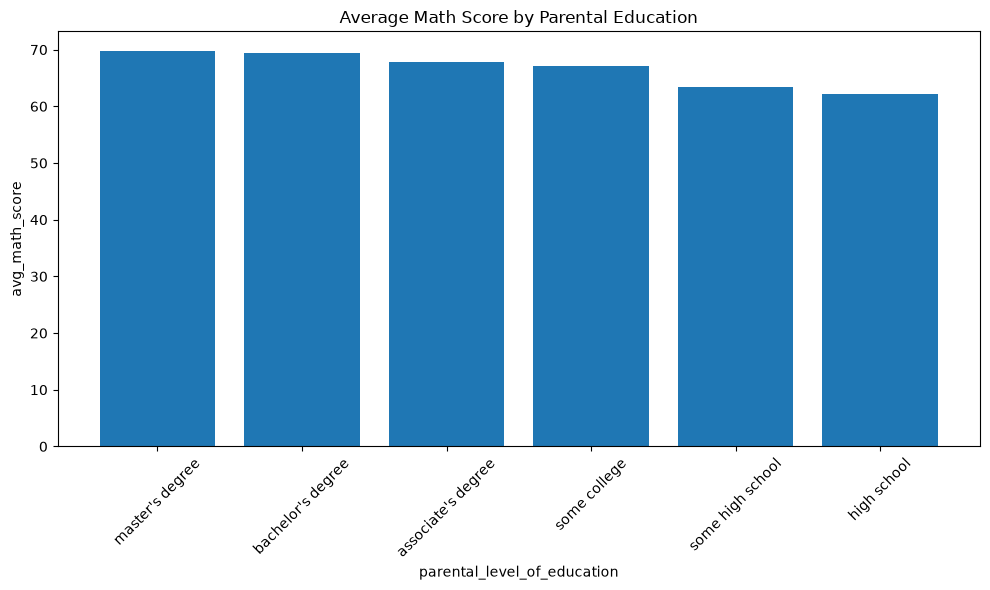


📊 Tool result:
{'status': 'success', 'chart_type': 'bar', 'result_id': 'd1b919cf'}

🤖 Gemini thinking...

🔧 Gemini selected: run_sql
📦 Arguments: {'query': 'SELECT \n    test_preparation_course, \n    AVG(math_score) as avg_math_score \nFROM data \nGROUP BY test_preparation_course;'}

🔧 TOOL CALL: run_sql
Arguments: {'query': 'SELECT \n    test_preparation_course, \n    AVG(math_score) as avg_math_score \nFROM data \nGROUP BY test_preparation_course;'}

📊 Tool result:
{'result_id': '09bfe08a', 'row_count': 2, 'columns': ['test_preparation_course', 'avg_math_score'], 'data': [{'test_preparation_course': 'completed', 'avg_math_score': 69.69553072625699}, {'test_preparation_course': 'none', 'avg_math_score': 64.0778816199377}]}

🤖 Gemini thinking...

🔧 Gemini selected: make_chart
📦 Arguments: {'title': 'Average Math Score by Test Preparation Course', 'result_id': '09bfe08a', 'x': 'test_preparation_course', 'chart_type': 'bar', 'y': 'avg_math_score'}

🔧 TOOL CALL: make_chart
Arguments: {'

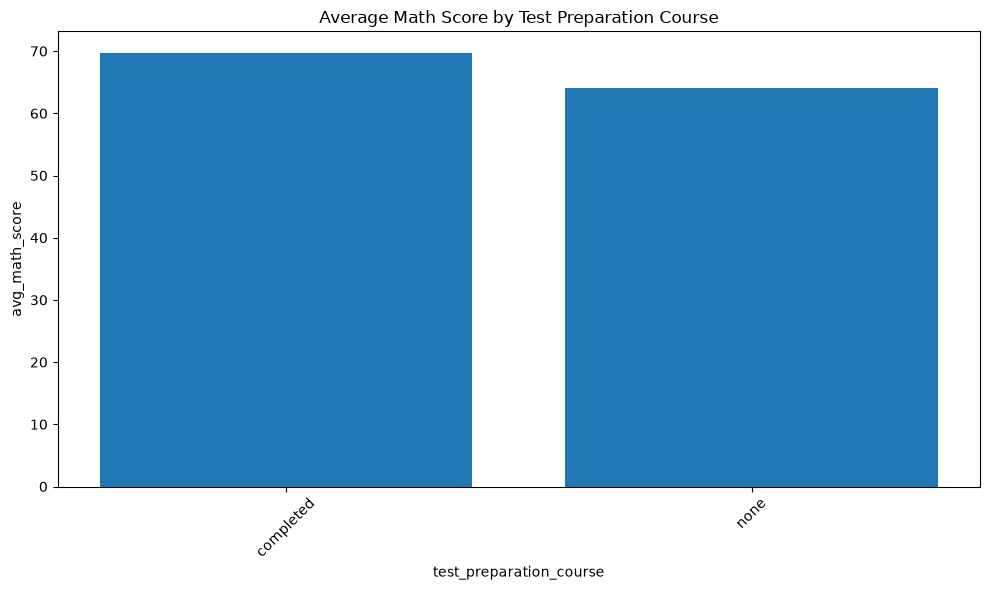


📊 Tool result:
{'status': 'success', 'chart_type': 'bar', 'result_id': '09bfe08a'}

🤖 Gemini thinking...

🔧 Gemini selected: run_sql
📦 Arguments: {'query': 'SELECT \n    lunch, \n    AVG(math_score) as avg_math_score \nFROM data \nGROUP BY lunch;'}

🔧 TOOL CALL: run_sql
Arguments: {'query': 'SELECT \n    lunch, \n    AVG(math_score) as avg_math_score \nFROM data \nGROUP BY lunch;'}

📊 Tool result:
{'result_id': 'b292f876', 'row_count': 2, 'columns': ['lunch', 'avg_math_score'], 'data': [{'lunch': 'free/reduced', 'avg_math_score': 58.92112676056338}, {'lunch': 'standard', 'avg_math_score': 70.03410852713178}]}

🤖 Gemini thinking...

🔧 Gemini selected: make_chart
📦 Arguments: {'x': 'lunch', 'chart_type': 'bar', 'title': 'Average Math Score by Lunch Type', 'result_id': 'b292f876', 'y': 'avg_math_score'}

🔧 TOOL CALL: make_chart
Arguments: {'x': 'lunch', 'chart_type': 'bar', 'title': 'Average Math Score by Lunch Type', 'result_id': 'b292f876', 'y': 'avg_math_score'}


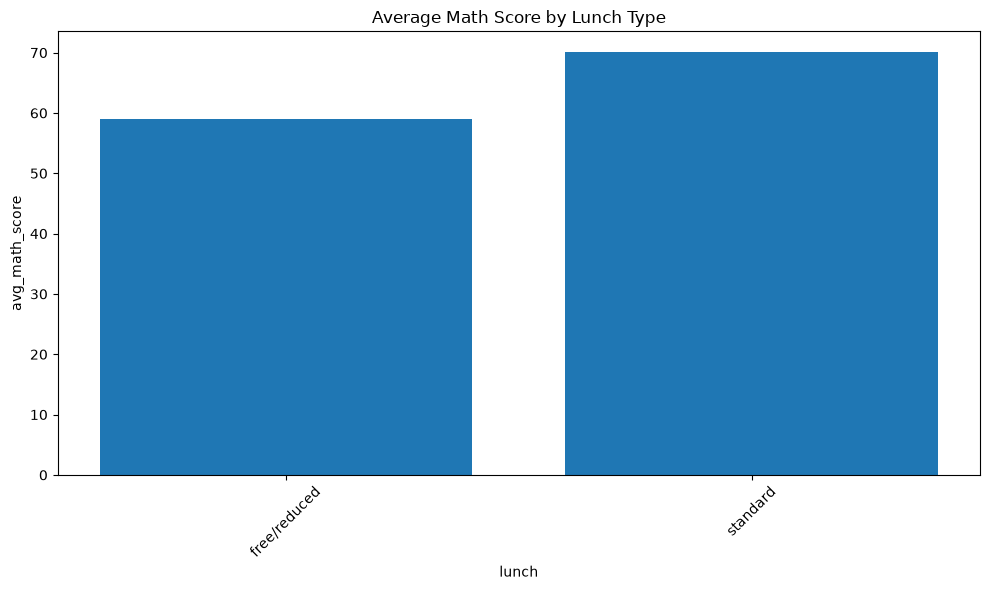


📊 Tool result:
{'status': 'success', 'chart_type': 'bar', 'result_id': 'b292f876'}

🤖 Gemini thinking...

FINAL ANSWER:
To understand what affects the `math_score`, I analyzed several categorical factors in the `data` table. Here are the key findings:

### Key Findings:
1.  **Lunch Type:** This has a significant impact. Students with a "standard" lunch perform notably better in math (average ~70) compared to those with "free/reduced" lunch (average ~59).
2.  **Test Preparation Course:** Students who completed the test preparation course achieved higher math scores (average ~70) compared to those who did not (average ~64).
3.  **Parental Level of Education:** There is a positive correlation between the parents' education level and the students' math scores. Students whose parents have a Master's or Bachelor's degree tend to have higher average math scores than those whose parents have a high school education.

### Visualizations:
I have generated charts for these factors to help you vi

In [34]:
answer = ask_agent(
    "tell me what affect the mathscore.and the table name is data.and also prepare plots" 
)

print("\nFINAL ANSWER:")
print(answer)